# RL - Chapter 4 - DP - Gambler's Problem


In [361]:
from toc import generate_toc

path = 'ch_4_DP_p3_gambler.ipynb'
generate_toc(path)

## Table of Contents

- [RL - Chapter 4 - DP - Gambler's Problem](#rl-chapter-4-dp-gamblers-problem)
  - [Environment - Physics](#environment-physics)
  - [Policy](#policy)
  - [Dynamic Programming Agent](#dynamic-programming-agent)
  - [Run Policy Iteration](#run-policy-iteration)

In [362]:
import numpy as np
import matplotlib.pyplot as plt

# set decimal precision for numpy arrays
np.set_printoptions(precision=1, suppress=True)

## Environment - Physics


In [363]:
# Gambler's problem environment
class GamblerEnv:
    def __init__(self):
        self.h_p = 0.40  # probability of winning
        self.h_l = 1 - self.h_p  # probability of losing
        self.max_capital = 100  # goal capital
        self.states = np.arange(self.max_capital + 1)  # states: 0 to 100
        self.n_states = len(self.states)
        self.goal_state = self.max_capital
        self.state_action_space = {}

        self.create_state_action_space()

    def get_actions(self, state):
        if state == 0 or state == self.max_capital:
            return [0]
        return np.arange(1, min(state, self.max_capital - state) + 1)

    def create_state_action_space(self):
        for state in self.states:
            self.state_action_space[state] = self.get_actions(state)

## Policy


In [364]:
# define Policy
class Policy:
    def __init__(self, env: GamblerEnv):
        # policy pi(a|s) : an action for each state
        self.pi = np.ones(env.n_states, dtype=np.int32)
        self.initialize_policy(env.n_states)

    def initialize_policy(self, n_states):
        self.pi = np.ones(n_states, dtype=np.int32)

## Dynamic Programming Agent


In [365]:
# Dynamic Programming Agent
class DP_Agent:
    def __init__(self, env: GamblerEnv):

        # initialize environment(dynamics) and policy
        self.env = env              # Environment
        self.policy = Policy(env)   # Policy

        # setting hyperparameters
        self.gamma = 1.0            # Discount factor
        self.theta = 1e-6           # Convergence threshold
        self.max_policy_iter = 100
        self.max_value_iter = 100
        self.max_policy_eval_sweep = 100

        # initialize value function
        self.v_history = []
        self.V = np.zeros(self.env.n_states, dtype=np.float32)  # V[s] = value of state s
        self.V[self.env.goal_state] = 0.0  # set value of goal state to 1
        self.v_sum = 0.0

        # counters for diagnostics
        self.n_policy_imp = 0
        self.n_policy_eval_sweep = 0
        self.n_value_iter = 0

    def reset(self):
        self.V = np.zeros(self.env.n_states, dtype=np.float32)
        self.policy.initialize_policy(self.env.state_action_space)
        self.n_policy_imp = 0
        self.n_policy_eval_sweep = 0
        self.n_value_iter = 0

    # --------------------------------------------------------------------------
    # Policy Iteration and Value Iteration
    # --------------------------------------------------------------------------

    def policy_iteration(self):
        print("Starting policy iteration. \n++++++++++++++++ ")
        self.n_policy_imp = 0
        while True:
            self.policy_evaluation()
            policy_stable = self.policy_improvement()

            self.v_sum = np.sum(self.V)
            self.n_policy_imp += 1
            self.v_history.append(self.V.copy())

            if policy_stable:
                print("\nPolicy iteration converged.\n")
                break
            if self.n_policy_imp > self.max_policy_iter:
                print(f"\nPolicy iteration did not converge within {self.max_policy_iter} iterations.\n")
                break

    def value_iteration(self):
        print("Starting value iteration. \n++++++++++++++++ ")
        self.n_value_iter = 0
        for i in range(self.max_value_iter):
            delta = 0.0
            self.n_value_iter += 1
            for s in self.env.states[1:-1]:  # skip terminal state
                v_old = self.V[s]
                action_values = []
                for action in self.env.state_action_space[s]:
                    action_value = self.get_expected_return(state=s, action=action)
                    action_values.append(action_value)
                v_new = max(action_values)
                self.V[s] = v_new
                delta = max(delta, abs(v_old - v_new))

            self.v_history.append(self.V.copy())

            # print(f"Value iteration #{i + 1}, delta: {delta:.3f}")
            if delta < self.theta:
                print("\nValue iteration converged.\n")
                break
        # derive policy from optimal value function
        print("\nDeriving policy from optimal value function.")
        for s in self.env.states[1:-1]:  # skip terminal state
            best_action = self.get_improved_action(state=s)
            self.policy.pi[s] = best_action

    # --------------------------------------------------------------------------
    # Policy evaluation and improvement
    # --------------------------------------------------------------------------

    def policy_evaluation(self):
        print(f"Starting policy evaluation #{self.n_policy_eval_sweep + 1} . -------------")
        while True:
            delta = 0.0
            self.n_policy_eval_sweep += 1
            for s in self.env.states[1:-1]:  # skip terminal state
                # expected_return
                action_value = self.get_expected_return(state=s, action=self.policy.pi[s])
                v_new = action_value

                # update value function and track max change for convergence check
                delta = max(delta, abs(self.V[s] - v_new))
                self.V[s] = v_new

            # print(f"policy evaluation #{self.n_policy_eval_sweep}, delta: {delta:.3f}")
            if delta < self.theta:
                break
            if self.n_policy_eval_sweep >= self.max_policy_eval_sweep:
                print(f"Policy evaluation did not converge within {self.max_policy_eval_sweep} iterations.")
                break

    def policy_improvement(self):
        print(f"Starting policy improvement #{self.n_policy_imp + 1} . -------------")
        policy_stable = True
        for s in self.env.states[1:-1]:  # skip terminal state
            # update policy
            curr_action = self.policy.pi[s]
            new_action = self.get_improved_action(state=s)
            self.policy.pi[s] = new_action

            # check if policy is stable
            if curr_action != new_action:
                policy_stable = False

        return policy_stable

    def get_improved_action(self, state):
        action_returns = []
        for action in self.env.state_action_space[state]:
            action_value = self.get_expected_return(state=state, action=action)
            action_returns.append(action_value)
        best_action = self.env.state_action_space[state][np.argmax(action_returns)]
        return best_action

    # --------------------------------------------------------------------------
    # Expected return calculation
    # --------------------------------------------------------------------------

    def get_expected_return(self, state, action):
        # for gamber's problem
        # The reward is zero on all transitions except those that end in the goal state, where it is +1.
        action_value = 0.0
        for outcome in [0, 1]:  # 0 = lose, 1 = win
            prob = self.env.h_p if outcome == 1 else self.env.h_l
            next_state = state + action if outcome == 1 else state - action
            reward = 1.0 if next_state == self.env.goal_state else 0.0
            reward *= outcome
            if next_state < 0:
                raise ValueError(f"Next state {next_state} is out of bounds (negative). Check action and state.")

            next_state = min(next_state, self.env.max_capital)  # ensure next state is within bounds
            action_value += prob * (reward + self.gamma * self.V[next_state])
        return action_value

## Run Policy Iteration


In [366]:
env = GamblerEnv()

# create DP agent
agent = DP_Agent(env)

# policy iteration
agent.policy_iteration()

print("\nState-Value Function:")
print(f"Policy improvement steps: {agent.n_policy_imp}")
print(f"Total evaluation sweeps: {agent.n_policy_eval_sweep}")

Starting policy iteration. 
++++++++++++++++ 
Starting policy evaluation #1 . -------------
Policy evaluation did not converge within 100 iterations.
Starting policy improvement #1 . -------------
Starting policy evaluation #101 . -------------
Policy evaluation did not converge within 100 iterations.
Starting policy improvement #2 . -------------
Starting policy evaluation #102 . -------------
Policy evaluation did not converge within 100 iterations.
Starting policy improvement #3 . -------------
Starting policy evaluation #103 . -------------
Policy evaluation did not converge within 100 iterations.
Starting policy improvement #4 . -------------
Starting policy evaluation #104 . -------------
Policy evaluation did not converge within 100 iterations.
Starting policy improvement #5 . -------------
Starting policy evaluation #105 . -------------
Policy evaluation did not converge within 100 iterations.
Starting policy improvement #6 . -------------
Starting policy evaluation #106 . ----

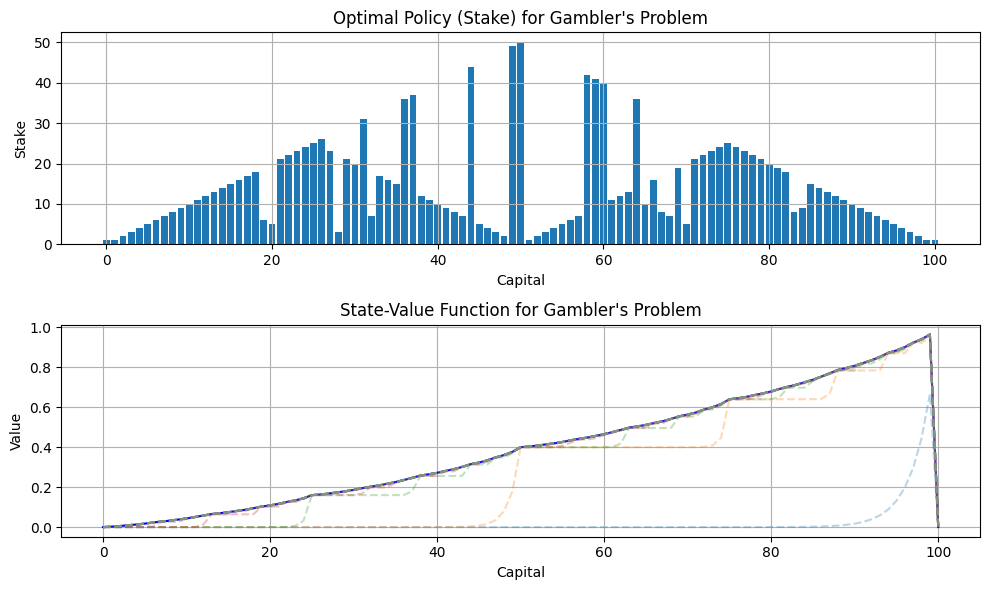

In [367]:
# display final policy as a grid

fig, ax = plt.subplots(2, 1, figsize=(10, 6), tight_layout=True)
ax[0].bar(height=agent.policy.pi, x=np.arange(len(agent.policy.pi)))
ax[0].set_title("Optimal Policy (Stake) for Gambler's Problem")
ax[0].set_xlabel("Capital")
ax[0].set_ylabel("Stake")
ax[0].grid()
# display value function
ax[1].plot(agent.V, '-b')
for vh in agent.v_history:
    ax[1].plot(vh, '--', alpha=0.3)
ax[1].set_title("State-Value Function for Gambler's Problem")
ax[1].set_xlabel("Capital")
ax[1].set_ylabel("Value")
ax[1].grid()
plt.show()

In [368]:
# create DP agent
agent = DP_Agent(env)

# value iteration
agent.value_iteration()

# print results
print(f"Value iteration steps: {agent.n_value_iter}")

Starting value iteration. 
++++++++++++++++ 

Value iteration converged.


Deriving policy from optimal value function.
Value iteration steps: 12


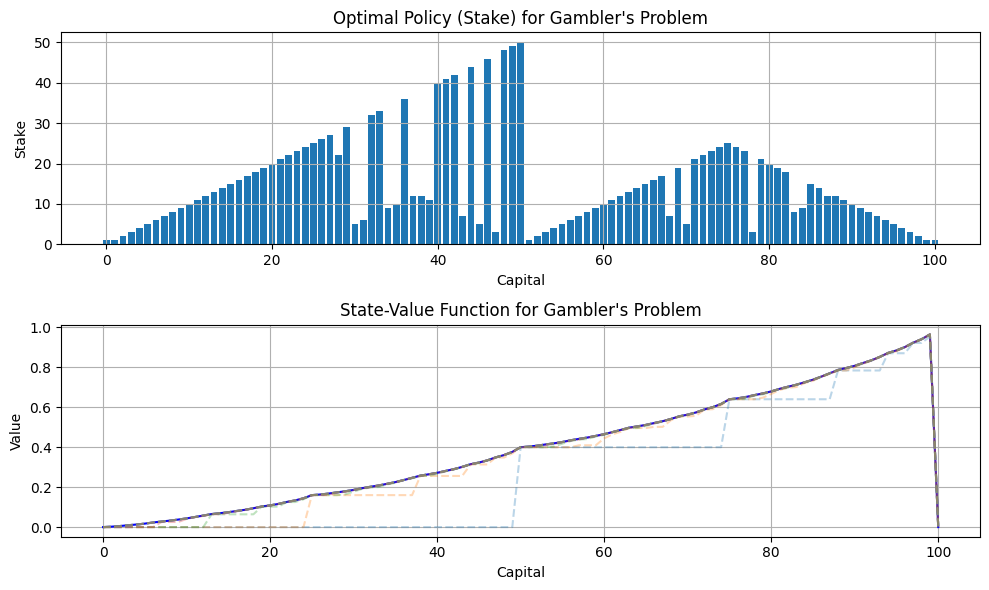

In [369]:
# display final policy as a grid

fig, ax = plt.subplots(2, 1, figsize=(10, 6), tight_layout=True)
ax[0].bar(height=agent.policy.pi, x=np.arange(len(agent.policy.pi)))
ax[0].set_title("Optimal Policy (Stake) for Gambler's Problem")
ax[0].set_xlabel("Capital")
ax[0].set_ylabel("Stake")
ax[0].grid()
# display value function
ax[1].plot(agent.V, '-b')
for vh in agent.v_history:
    ax[1].plot(vh, '--', alpha=0.3)
ax[1].set_title("State-Value Function for Gambler's Problem")
ax[1].set_xlabel("Capital")
ax[1].set_ylabel("Value")
ax[1].grid()
plt.show()